<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 5: Neural Network Modules

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li> 
    <li><a href='#buildingblocks' style="color:black;">PyTorch Building Blocks of Neural Networks</a></li>
    <li><a href='#firstexample' style="color:black;">Example: Polynomial Regression</a></li>    
    <li><a href='#background_linear' style="color:#1B5E20;"><strong>Background:</strong> Linear and Affine Transformations</a></li>     
    <li><a href='#linearmodule' style="color:black;">Defining Linear Layers</a></li>    
    <li><a href='#classnetwork' style="color:black;">Class-Based Network Design</a></li>      
    <li><a href='#modelstructure' style="color:black;">Exploring Model Structure and Parameters</a></li>     
    <li><a href='#background_sgd' style="color:#1B5E20;"><strong>Background:</strong> Stochastic Gradient Descent and Beyond</a></li>
    <li><a href='#modeltraining' style="color:black;">Model Training and Optimization</a></li>      
    <li><a href='#secondexample' style="color:black;">Example: Piecewise Linear Approximation</a></li>    
    <li><a href='#exercise_activation_function' style="color:#006064;"><strong>Exercise 1:</strong> Activation Functions</a></li>
    <li><a href='#exercises_model_capacity' style="color:#006064;"><strong>Exercise 2:</strong> Exploring Model Capacity</a></li>
    <li><a href='#exercise_optimization' style="color:#006064;"><strong>Exercise 3:</strong> Optimization</a></li>    
</ul>  

<a id='learn'></a>  
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This unit introduces the essential components of <strong>neural network construction</strong> and <strong>training</strong> using PyTorch's <code>torch.nn</code> module. As the core API for deep learning in PyTorch, <code>torch.nn</code> provides the building blocks required to define modular network architectures, manage learnable parameters, and perform optimization using standardized tools. The learning objectives of this unit are as follows: 
</p>

<ul style="color:#E65100;">
<li>Explain the role of <code>nn.Module</code> as the base class for building neural networks and how it relates to layers and models.</li>
<li>Build and organize networks using both built-in layers (e.g., <code>nn.Linear</code>) and self-defined layers with <code>forward()</code> methods.</li>
<li>Explore the internal structure and parameters of neural networks using methods such as <code>model.parameters()</code> and <code>model.named_parameters()</code>.</li>
<li>Apply activation functions such as <code>ReLU</code>, <code>sigmoid</code>, and <code>tanh</code> as non-linear components in multi-layer networks.</li>
<li>Use loss functions (e.g., <code>nn.MSELoss</code>) and optimizers (e.g., <code>optim.SGD</code>) to perform iterative model training.</li>
<li>Implement forward and backward passes, gradient resets, and optimization steps in PyTorch's training pipeline.</li>
<li>Compare writing your own optimization loop with using <code>torch.optim</code to learn how PyTorch supports different training styles.</li>
<li>Understand parameter initialization and explore the model's parameter space.</li>
<li>Experiment with deeper networks and convolutional filters for function approximation and signal smoothing.</li>
</ul>

<p style="color:#E65100;">
The unit includes three hands-on exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_activation_function">Exercise 1</a>: Explore the behavior of common nonlinear activation functions.</li>
<li><a href="#exercises_model_capacity">Exercise 2</a>: Investigate the effects of increased model capacity.</li>
<li><a href="#exercise_optimization">Exercise 3</a>: Explore different optimization strategies and convergence behavior.</li>
</ul>

<p style="color:#E65100;">
The unit builds on the polynomial regression example from <a href="PCPT_04_grad.html">Unit 4</a> and extends it to more general and flexible neural network models. For more information about PyTorch's modular network design, see the official <a href="https://pytorch.org/docs/stable/nn.html" target="_blank">PyTorch nn documentation</a> and the tutorial on <a href="https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html" target="_blank">Building Neural Networks</a>.
</p>
</div>

In [1]:
# --- Core scientific stack ---
import torch
from torch import nn
import torch.optim as optim
from torchinfo import summary

# --- Custom utilities (Unit 5) ---
from libpcpt.unit05 import (
    generate_training_pairs,
    plot_training_pairs_model,
    exercise_activation_function,
    exercise_activation_function_experiment,
    exercises_model_capacity,
    exercise_optimization
)

<a id='buildingblocks'></a> 
## PyTorch Building Blocks of Neural Networks

The `torch.nn` package is central to building and training neural networks in PyTorch. It provides the essential **modules**, tools, and abstractions needed to define network architectures, manage trainable parameters, and perform end-to-end optimization. In PyTorch, the term **module** refers to any component that processes input tensors to produce output tensors&mdash;this includes layers like fully connected, convolutional, or recurrent layers, as well as entire network models composed of such layers. Each module can contain other modules, enabling hierarchical and modular design. Here is an overview of the key components and utilities offered by `torch.nn`:

* **Modules**: The foundation of any PyTorch network is `nn.Module`, the base class from which all layers and custom models inherit. It handles internal structures, submodules, and parameter management. Built-in modules include commonly used layers like `nn.Linear`, `nn.Conv1d`, and `nn.RNN`.

* **Activation functions**: `torch.nn` includes standard non-linearities such as `ReLU`, `Sigmoid`, and `Tanh`. These are essential for introducing non-linear behavior into networks and enabling them to model complex relationships.

* **Loss functions**: Loss functions such as `nn.MSELoss` and `nn.CrossEntropyLoss` quantify how well the model predictions match the target values. They guide the optimization process during training by providing the gradients needed to update parameters.

* **Optimizers**: While defined in the <code>torch.optim</code> module, optimizers such as <code>SGD</code> and <code>Adam</code> work seamlessly with models built using <code>torch.nn</code>. They update the model's parameters automatically based on the computed gradients, the learning rate, and other configuration settings.

* **Functional interface**: The `torch.nn.functional` submodule provides low-level functions for operations like linear transformations, activations, and convolutions. Unlike `nn.Module` layers, these functions do not store learnable parameters or states. They are often used directly in the `forward()` method when building custom layers or experimenting with new ideas.</p>

* **Functional interface**: The `torch.nn.functional` submodule provides low-level functions for operations like linear transformations, activations, and convolutions. Unlike `nn.Module` layers, these functions do not store learnable parameters or states. This makes them useful for implementing custom behavior directly in the `forward()` method—especially when more control or flexibility is needed than what built-in modules offer.

* **Weight initialization**: Proper initialization of weights is important for training deep networks effectively. The `torch.nn.init` submodule provides commonly used strategies that help control the variance of activations and gradients throughout the network.

By combining these elements, <code>torch.nn</code> gives developers a practical toolkit for building and training neural networks step by step, while keeping full control over how computations are defined and executed.

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong>
In PyTorch, the term <strong>module</strong> refers to any component that behaves like a neural network layer&mdash;such as a linear transformation, activation function, or even an entire sub-network. These are all subclasses of <code>torch.nn.Module</code>. In traditional deep learning terminology, such components are typically called <strong>layers</strong>. So, in PyTorch, a <strong> layer</strong>  is implemented as a <strong> module</strong> . This can be confusing because in standard Python, a <a href="https://docs.python.org/3/tutorial/modules.html"><strong>module</strong></a> refers to a file containing Python definitions and code (i.e., a <code>.py</code> file that can be imported). PyTorch's use of the term <strong>module</strong> is entirely unrelated to this Python concept. When working with <code>torch.nn</code>, always remember: PyTorch modules are the <strong> functional units</strong>  of a neural network&mdash;not Python source files.
</p>
</div>

<a id='firstexample'></a> 
## Example: Polynomial Regression

To give a concrete first impression of how `torch.nn` works in practice, we revisit the polynomial regression example from <a href="PCPT_04_grad.html">Unit 4</a>. The task is to approximate a non-linear function using a set of training pairs: an input array `x` and a corresponding target array `y`. This simple scenario provides an intuitive entry point for introducing neural network components such as linear layers, loss functions, and optimizers. In this first example, we walk through a complete training loop using `torch.nn` modules&mdash;detailed explanations for each step will follow afterwards.

Number of training pairs: 100


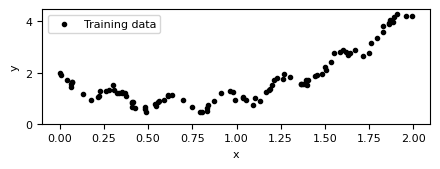

In [2]:
# Generate training data (same as in Unit 4)
x, y = generate_training_pairs()

# Print number of training pairs
B = x.shape[0]
print(f"Number of training pairs: {B}")

# Visualize the target function
plot_training_pairs_model(x, y)

For this example, we model the prediction `y_pred` as a linear function of `x` and `x**2`. This corresponds to a second-degree polynomial regression, which can be effectively implemented using a simple linear layer in a neural network. The goal of this first example is to demonstrate the overall training pipeline using the `torch.nn` package. The main steps involved are as follows:

* **Data preparation**: We create tensors to store the input and target values. The input tensor has two dimensions: the first represents the **batch dimension** (in our case this is the number of training samples), and the second corresponds to the number of input features. In this example, each input consists of two features: `x` and `x**2`. Therefore, the input tensor has shape `(B, 2)`, where `B` is the number of training pairs.

* **Model definition**: We use `torch.nn.Linear` to create a model that linearly maps the two input features to a single output.
* **Loss function**: We define a mean squared error (MSE) loss using `torch.nn.MSELoss`, which quantifies the prediction error.
* **Forward pass**: We compute the model output for the input data.
* **Gradient reset**: Before computing new gradients, we zero out any existing gradients using `.zero_grad()`.
* **Backward pass**: We use `loss.backward()` to compute the gradients of the loss with respect to the model parameters.
* **Parameter update**: Finally, we perform a manual gradient descent step to update the parameters and minimize the loss.

This full example provides a concrete and intuitive introduction to neural network modules, which we will examine in depth throughout the rest of the unit.

Iteration 1000 | Loss: 0.1919


Iteration 2000 | Loss: 0.1274


Iteration 3000 | Loss: 0.0923


Iteration 4000 | Loss: 0.0732



Learned Parameters:
a = 1.4412, b = -2.0275, c = 1.7172


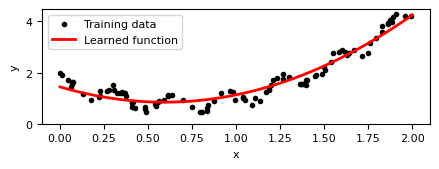

In [3]:
# --- Data Preparation ---
# Shape of y: (B, 1) to match output format of linear layer
y = y.unsqueeze(1)

# Construct input tensor with two features: x and x**2
# Shape of x: (B, 2)
x = torch.stack([x, x.pow(2)], dim=1)

# --- Model Definition ---
# Set random seed for reproducibility
torch.manual_seed(0)

# Define a linear layer with 2 input features and 1 output
model = torch.nn.Linear(in_features=2, out_features=1)

# --- Loss Function ---
# Use mean squared error
loss_fn = torch.nn.MSELoss()

# --- Optimization Settings ---
learning_rate = 1e-2
num_iterations = 4000

# --- Training Loop ---
for k in range(1, num_iterations + 1):
    # Forward pass: compute predictions
    y_pred = model(x)

    # Compute loss
    loss = loss_fn(y_pred, y)
    
    # Print loss every 1000 iterations
    if k % 1000 == 0:
        print(f"Iteration {k:4d} | Loss: {loss.item():.4f}", flush=True)
    
    # Zero gradients from previous iteration
    model.zero_grad()

    # Backward pass: compute gradients
    loss.backward()

    # Update parameters manually using gradient descent
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad

# --- Extract Trained Parameters ---
# Access bias and weights from the trained linear layer
a = model.bias.item()
b = model.weight[0, 0].item()
c = model.weight[0, 1].item()

print(f"\nLearned Parameters:\na = {a:.4f}, b = {b:.4f}, c = {c:.4f}")

# --- Plot Result ---
plot_training_pairs_model(x[:, 0], y.squeeze(), para=[a, b, c])

This example builds directly on the manual training loop introduced in <a href="PCPT_04_grad.html">Unit 4</a>, where we optimized scalar parameters using PyTorch's <code>autograd</code> system. While the overall structure remains the same, this new implementation transitions toward a more modular and scalable design using the <code>torch.nn</code> package. The main differences are summarized below:

* **Model definition**: In Unit 4, the model was defined explicitly using scalar parameters <code>a</code>, <code>b</code>, and <code>c</code>. Here, we use <code>torch.nn.Linear</code> to define a linear model with two input features and one output. This module automatically manages its weights and bias and can be reused as a building block in larger networks.

* **Loss function**: Previously, the mean squared error (MSE) was computed manually using tensor operations. Now we use <code>torch.nn.MSELoss</code>, which is part of PyTorch's standard library of loss functions, making the implementation more compact and flexible.

* **Gradient reset**: In Unit 4, gradients were reset individually by assigning <code>.grad = None</code> for each parameter. With <code>torch.nn</code>, we can reset all gradients at once using <code>model.zero_grad()</code>.

* **Parameter management**: Instead of manually updating scalar variables, we now iterate over <code>model.parameters()</code> to access and update all trainable parameters. This design generalizes to models of arbitrary complexity.

* **Scalability**: The <code>torch.nn</code> version is structured to support more complex network architectures and larger datasets. While Unit 4 gave insight into gradient mechanics, this unit shows how to use PyTorch's abstractions to build and train models more efficiently.

This comparison highlights how moving from manual setups to modular components not only simplifies code but also prepares us for designing deeper and more powerful neural networks in future units.

<a id='background_linear'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Linear and Affine Transformations</h2>

<p style="color:#1B5E20;">
Linear and affine transformations are core concepts in linear algebra and appear in many fields&mdash;from physics and geometry to computer graphics and machine learning. A <strong>linear transformation</strong> preserves the fundamental structure of vector spaces, including operations like addition and scalar multiplication. Common geometric operations such as rotation, scaling, and projection are linear, and because they can be represented efficiently with matrices, they form the backbone of many computational systems. From a mathematical perspective, we consider finite-dimensional Euclidean vector spaces. A <strong>linear transformation</strong> is a function $f: \mathbb{R}^N \rightarrow \mathbb{R}^M$ that satisfies:
</p>

<ul style="color:#1B5E20;">
<li><strong>Additivity:</strong> $f(\mathbf{x} + \mathbf{y}) = f(\mathbf{x}) + f(\mathbf{y})$ for all $\mathbf{x}, \mathbf{y} \in \mathbb{R}^N$</li>
<li><strong>Homogeneity:</strong> $f(\alpha \mathbf{x}) = \alpha f(\mathbf{x})$ for all $\alpha \in \mathbb{R}$ and $\mathbf{x} \in \mathbb{R}^N$</li>
</ul>

<p style="color:#1B5E20;">
These properties ensure that a transformation preserves the geometric structure of space: lines remain straight, the origin is fixed, and scaling inputs by a scalar results in proportionally scaled outputs. Any such transformation can be represented by a matrix $\mathbf{W} \in \mathbb{R}^{M \times N}$ as
$$
f(\mathbf{x}) = \mathbf{W} \mathbf{x}.
$$
An <strong>affine transformation</strong> extends a linear transformation by adding a constant offset or <strong>bias</strong> $\mathbf{b} \in \mathbb{R}^M$:
$$
f(\mathbf{x}) = \mathbf{W} \mathbf{x} + \mathbf{b}
$$
Although not strictly linear, affine transformations preserve important geometric properties such as parallelism and are widely used in geometry, robotics, computer graphics, and statistical modeling. In <strong>deep learning</strong>, affine transformations are implemented by layers such as <code>torch.nn.Linear</code>, which apply
$$
\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}
$$
to each input vector $\mathbf{x} \in \mathbb{R}^N$, producing transformed outputs $\mathbf{z} \in \mathbb{R}^M$. During training, the weights $\mathbf{W}$ and bias $\mathbf{b}$ are learned from data. When applied to a batch of inputs $\mathbf{X} \in \mathbb{R}^{B \times N}$, the affine transformation becomes
$$
\mathbf{Z} = \mathbf{X} \mathbf{W}^\top + \mathbf{b}^\top.
$$
The transposed bias vector $\mathbf{b}^\top$, viewed as a row vector, is <strong>broadcasted</strong> across all $B$ rows; that is, it is added elementwise to each row of the matrix product, resulting in the output matrix $\mathbf{Z} \in \mathbb{R}^{B \times M}$. In summary, linear and affine transformation are foundational for neural network learning:
</p>

<ul style="color:#1B5E20;">
<li>They serve as the <strong>initial transformation</strong> that reshapes raw input into feature representations more suitable for learning patterns.
<li>They are <strong>computationally efficient</strong> and <strong>mathematically easy</strong> to analyze, making them well-suited for optimization methods like gradient descent.</li>
<li>When stacked and combined with non-linear activations, they allow networks to model arbitrary functions&mdash;an idea formalized by the <a href="https://en.wikipedia.org/wiki/Universal_approximation_theorem"><strong>universal approximation theorem</strong></a>.</li>
</ul>
</div>

<a id='linearmodule'></a> 
## Defining Linear Layers

Let us now explore the model component of the training pipeline in more detail. The `torch.nn.Linear` class defines a linear layer, often referred to as a **fully connected** or **dense** layer. This layer performs an affine transformation on its input, which can be described as <code>output = input &times; weight + bias</code>. In this formulation:

* `input` typically represents a matrix (or tensor), where each row is a data point. The first dimension usually represents the batch.
* `weight` is a matrix that applies a linear transformation to the input.
* `bias` is an optional vector added to each transformed input, allowing the model to shift the output.

Both the `weight` and `bias` parameters are **learned** during training. To define such a layer in PyTorch, one uses the `torch.nn.Linear` class and specifies the number of input and output features. For instance, [`torch.nn.Linear(N, M, bias=True)`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) creates a linear layer where:

* The input tensor has shape `(*, N)`, where `*` represents any number of leading dimensions (such as batch size), and `N` is the number of input features.
* The output tensor has shape `(*, M)`, maintaining the same leading dimensions, with `M` denoting the number of output features.

The module includes two learnable tensors: a weight matrix of size `M x N` and a bias vector of length `M`. These parameters are initialized automatically using predefined random distributions. Note that the `*` notation means that the linear layer is flexible enough to handle different batch sizes and higher-dimensional inputs. For example, an input tensor of shape `(B, N)` results in an output of shape `(B, M)`.

In our earlier example, we used `torch.nn.Linear(2, 1)` and applied it to an input matrix `x` of shape `(B, 2)`, where `B = 100` is the number of training samples. Each input consists of two features (`x` and `x**2`), and the model outputs a single value per sample. This corresponds to an input dimension `N = 2` and an output dimension `M = 1`. Let us now examine the shapes of the input, output, and the model parameters to better understand how the linear layer operates:

In [4]:
# Examine the model structure and tensor shapes
print("Shape of input tensor:", x.shape)       # (number of samples, number of features)
print("Shape of output tensor:", y_pred.shape) # (number of samples, output dimension)

# Inspect the internal structure of the linear layer
print("Linear layer:", model)
print("Weight matrix shape:", model.weight.shape)
print("Weight values:\n", model.weight)
print("Bias shape:", model.bias.shape)
print("Bias values:\n", model.bias)

Shape of input tensor: torch.Size([100, 2])
Shape of output tensor: torch.Size([100, 1])
Linear layer: Linear(in_features=2, out_features=1, bias=True)
Weight matrix shape: torch.Size([1, 2])
Weight values:
 Parameter containing:
tensor([[-2.0275,  1.7172]], requires_grad=True)
Bias shape: torch.Size([1])
Bias values:
 Parameter containing:
tensor([1.4412], requires_grad=True)


<a id='classnetwork'></a>
## Class-Based Network Design

So far, we have used pre-defined modules such as `torch.nn.Linear` to apply affine transformations in a neural network. This modular approach is simple and works well for many basic tasks. However, it becomes limiting when building more advanced models. For example, one might want to include multiple layers, reuse certain components, or implement input-dependent computation paths. To address such cases, PyTorch allows us to define neural networks more flexibly by creating **Python classes** that inherit from `torch.nn.Module`. This object-oriented approach provides a systematic way as follows:

* Organize the components of a custom model.
* Automatically track and register its learnable parameters.
* Define the forward computation performed by the custom model.
* Reuse and extend model architectures across different tasks.

In this context, a **custom model** refers to a neural network that you define yourself&mdash;rather than using a pre-built module. It typically combines existing layers or implements new computation logic suited to a specific task.

At this point, we assume that you are familiar with Python classes, as discussed in [Unit 2](PCPT_02_classes.html) of this course. The module `torch.nn.Linear`, which we used earlier, is itself a **child class** of `torch.nn.Module`—the base class from which all PyTorch network modules are derived. To define your own network in PyTorch, two core steps are required:

* In the constructor method `__init__()`, define and assign the necessary layers (e.g., instances of `torch.nn.Linear`).
* In the `forward()` method, specify how the input data should be processed during the forward pass.

Let us now look at a simple example where we define a class `NeuralNetLinear` that contains a single linear layer. After creating an instance of this class, we can print its structure using `print(model)`.

In [5]:
# Define a neural network class with a single linear layer
class NeuralNetLinear(nn.Module):
    def __init__(self):
        super().__init__()                   # Call the base class constructor
        self.linear_model = nn.Linear(2, 1)  # Define one linear layer

    def forward(self, x):
        return self.linear_model(x)          # Apply the linear layer to input x

# Create an instance of the network and print its structure
model = NeuralNetLinear()
print(model)

NeuralNetLinear(
  (linear_model): Linear(in_features=2, out_features=1, bias=True)
)


Here are some additional notes, along with a brief recap from [Unit 2](PCPT_02_classes.html), to help clarify the definition and behavior of the `NeuralNetLinear` class:

* `__init__(self)` is a special method in Python classes known as the **constructor**. It is automatically invoked when a new instance of the class is created.  
* `super().__init__()` calls the constructor of the **parent class** (`nn.Module` in this case). This ensures that the internal mechanisms of the base class are properly initialized before setting up the components of the new class.  
* Inside the `__init__` method, one defines the layers or submodules that make up the network, particularly those with learnable parameters. In our example, the network consists of a single linear layer, defined as `nn.Linear(2, 1)` and stored as the instance attribute `self.linear_model`.  
* The `forward(self, x)` method specifies how input data is transformed into output. This is where you define the computation that occurs during the **forward pass**. In our case, the forward pass simply applies the linear transformation to the input `x`.


<a id='modelstructure'></a>
## Exploring Model Structure and Parameters

The class `nn.Module` serves as the foundation for building neural networks in PyTorch. When you define a model by subclassing `nn.Module`, such as `NeuralNetLinear`, PyTorch automatically tracks all submodules (e.g., layers) and learnable parameters (e.g., weights and biases) that are defined inside the constructor method `__init__()`. This automatic registration greatly simplifies model inspection, debugging, and optimization.

In PyTorch, a **learnable parameter** is stored as a special tensor of type `torch.nn.Parameter`.  
A `Parameter` behaves just like a regular `torch.Tensor`, but with one important difference: it is **automatically registered** as part of the model's parameters when assigned as an attribute of an `nn.Module`. This means that PyTorch will include it in the output of `model.parameters()` and update it during training whenever `requires_grad=True`. Typical examples of parameters are the **weight** and **bias** tensors in linear or convolutional layers. To explore the internal structure and parameters of a model, PyTorch provides several useful tools:

* `model._modules`: Returns an `OrderedDict` containing all submodules (such as layers) defined in `__init__()`. This matches the output of `print(model)`.  
* `model.parameters()`: Returns an iterator over all learnable parameters (instances of `torch.nn.Parameter` with `requires_grad=True`).
* `model.named_parameters()`: Like `parameters()`, but also includes the name of each parameter, which makes it useful for inspection and debugging.
* `tensor.numel()`: For any tensor, returns the total number of elements (e.g., the number of scalar values in a weight matrix or bias vector).  

Below is an example that prints out the structure and parameters of our `NeuralNetLinear` model:

<a id='modelstructure'></a>
## Exploring Model Structure and Parameters

The class `nn.Module` serves as the foundation for building neural networks in PyTorch. When you define a model by subclassing `nn.Module`, such as `NeuralNetLinear`, PyTorch automatically tracks all submodules (e.g., layers) and learnable parameters (e.g., weights and biases) defined inside the constructor. This automatic registration greatly simplifies model inspection, debugging, and parameter optimization. To explore the internal structure and parameters of a model, PyTorch provides several helpful tools:

* `model._modules`: Returns an `OrderedDict` containing all submodules (like layers) defined in `__init__()`. This matches the output of `print(model)`.
* `model.parameters()`: Returns an iterator over all learnable parameters, which are instances of `torch.nn.Parameter` with `requires_grad=True`.
* `model.named_parameters()`: Like `parameters()`, but also includes the name of each parameter—useful for inspection and debugging.
* `tensor.numel()`: For any tensor, returns the total number of elements (e.g., the number of scalar values in a weight matrix or bias vector).

Below is an example that prints out the structure and parameters of our `NeuralNetLinear` model:

Here are some additional notes&mdash;along with a brief recap from [Unit 2](PCPT_02_classes.html)&mdash;to help clarify the definition and behavior of the `NeuralNetLinear` class:

* `__init__(self)` is a special method in Python classes known as the **constructor**. It is automatically invoked when a new instance of the class is created.

* `super().__init__()` calls the constructor of the **parent class** (`nn.Module` in this case). This ensures that the internal mechanisms of the base class are properly initialized before setting up the components of the new class.

* Inside the `__init__` method, one defines the layers or submodules that make up the network&mdash;particularly those with learnable parameters. In our example, the network consists of a single linear layer, defined as `nn.Linear(2, 1)` and stored as the instance attribute `self.linear_model`.

* The `forward(self, x)` method specifies how input data is transformed into output. This is where you define the computation that occurs during the **forward pass**. In our case, the forward pass simply applies the linear transformation to the input `x`.

In [6]:
# Print model architecture
print("Model architecture:")
print(model)

# Show registered submodules defined in the constructor
print("Registered submodules (via model._modules):")
print(model._modules)
print()

# Display name, shape, and number of elements for each learnable parameter
print("Learnable parameters:")
for name, param in model.named_parameters():
    print(f"     Name: {name}; Shape: {param.shape}; Number of elements: {param.numel()}")

# Compute and display the total number of parameters
total = sum(param.numel() for param in model.parameters())
print(f"Total number of trainable parameters: {total}")

Model architecture:
NeuralNetLinear(
  (linear_model): Linear(in_features=2, out_features=1, bias=True)
)
Registered submodules (via model._modules):
{'linear_model': Linear(in_features=2, out_features=1, bias=True)}

Learnable parameters:
     Name: linear_model.weight; Shape: torch.Size([1, 2]); Number of elements: 2
     Name: linear_model.bias; Shape: torch.Size([1]); Number of elements: 1
Total number of trainable parameters: 3


All registered parameters are **automatically initialized** by PyTorch based on the type of layer. For example, in the case of `nn.Linear`, both weights and biases are initialized using a uniform distribution whose range depends on the number of input and output features. See the [PyTorch documentation](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear) for details. In the code cell below, we print all parameters of the `NeuralNetLinear` model as they are initialized by default. Each parameter is a PyTorch tensor with `requires_grad=True`, indicating that it will be updated during training.

In [7]:
# Display all initialized parameters in the NeuralNetLinear model
print("Initialized parameters of the NeuralNetLinear model:\n")
for name, param in model.named_parameters():
    print(f"Name: {name}")
    print(f"  Shape: {param.shape}")
    print(f"  Values:\n{param.data}")
    print(f"  requires_grad: {param.requires_grad}\n")

Initialized parameters of the NeuralNetLinear model:

Name: linear_model.weight
  Shape: torch.Size([1, 2])
  Values:
tensor([[-0.5204, -0.2723]])
  requires_grad: True

Name: linear_model.bias
  Shape: torch.Size([1])
  Values:
tensor([0.1896])
  requires_grad: True



<a id='background_sgd'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Stochastic Gradient Descent and Beyond</h2>

<p style="color:#1B5E20;">
Training deep learning models typically involves minimizing a loss function by adjusting model parameters. This process is most commonly guided by <strong>gradient-based optimization</strong> methods, which update parameters in the direction of steepest descent. As introduced in <a href="PCPT_04_grad.html">Unit 4</a>, in standard <strong>gradient descent</strong> the model parameters $\boldsymbol{\theta}$ are updated using the entire training dataset $\mathcal{D} = \{(\mathbf{x}^{(b)}, y^{(b)})\}_{b=1}^B$, consisting of $B$ training samples denoted by $(\mathbf{x}^{(b)}, y^{(b)})$:
$$
\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \gamma \cdot \nabla_{\boldsymbol{\theta}} \mathcal{L}(\mathcal{D}, \boldsymbol{\theta}^{(t)})
$$
Here, $\gamma > 0$ is the <strong>learning rate</strong>, and $\mathcal{L}$ denotes the loss function evaluated over the full dataset $\mathcal{D}$&mdash;typically by averaging or summing the losses over all samples. This principle forms the basis for many optimization algorithms in deep learning. A particularly important variant is <strong>Stochastic Gradient Descent (SGD)</strong>, where the parameter update is computed using a single randomly chosen training sample:
$$
\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \gamma \cdot \nabla_{\boldsymbol{\theta}} \mathcal{L}(\{(\mathbf{x}^{(b)}, y^{(b)})\}, \boldsymbol{\theta}^{(t)}).
$$
This process introduces randomness into the optimization, which can help the model avoid getting stuck in shallow local minima. It also reduces computation time per update, making the training process more efficient, especially when working with large datasets. In practice, instead of individual samples, deep learning libraries such as PyTorch implement SGD using <strong>mini-batches</strong>&mdash;randomly selected subsets of the training data. This approach provides a good trade-off between computational efficiency and the stability of parameter updates. 
<br><br>
To further improve the efficiency and stability of learning, SGD is often enhanced with <strong>momentum</strong>. The core idea is to simulate the motion of a particle in a loss landscape, where past gradients influence the current update. Instead of relying solely on the current gradient, momentum maintains a running average of previous gradients. This helps to smooth out oscillations and accelerates convergence in directions with consistent descent. The momentum-based update rule is given by:
$$
\mathbf{v}^{(t+1)} = \mu \cdot \mathbf{v}^{(t)} + \nabla_{\boldsymbol{\theta}} \mathcal{L}(\mathcal{B}, \boldsymbol{\theta}^{(t)}), \qquad
\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \gamma \cdot \mathbf{v}^{(t+1)},
$$
where $\mathbf{v}^{(t)}$ is the <strong>velocity vector</strong> at iteration $t$, storing an exponentially decayed sum of past gradients. The coefficient $\mu \in [0, 1)$ controls how much of the previous velocity is retained, $\gamma$ is the learning rate, and $\mathcal{B}$ denotes the mini-batch used to compute the gradient. Momentum helps to accelerate learning in the correct direction while reducing oscillations in regions with high curvature, leading to faster and more stable convergence on complex loss surfaces.
<br><br>
These are just a few examples of <strong>adaptive optimization algorithms</strong> commonly used in modern deep learning. Such methods can be easily configured and selected based on the model architecture, dataset size, and task-specific requirements. They offer efficient, scalable, and effective strategies for navigating complex loss landscapes. PyTorch provides a rich selection of these optimizers through its <a href="https://pytorch.org/docs/stable/optim.html"><code>torch.optim</code> module</a>, including:
</p>

<ul style="color:#1B5E20;">
<li><strong>Adam (Adaptive Moment Estimation):</strong> Combines momentum with per-parameter learning rates using running averages of the first and second moments of the gradients. It is widely used for its robustness and fast convergence.</li>
<li><strong>RMSProp:</strong> Normalizes gradients using a moving average of their squared values, which helps stabilize training in non-stationary or noisy environments.</li>
<li><strong>Adagrad:</strong> Modifies learning rates based on the accumulation of squared gradients, which reduces the step size for frequently updated parameters.</li>
</ul>
</div>

<a id='modeltraining'></a>  
## Model Training and Optimization

Having learned how to define and structure neural networks, we now focus on a central task in deep learning: **training the model** by optimizing its parameters. This means finding suitable values for the model's weights and biases so that a chosen **loss function** is minimized.

As introduced in [Unit 4](PCPT_04_grad.html) and further detailed in the previous background section, this optimization process is typically guided by **gradient-based methods**. In practice, this involves computing gradients using **backpropagation** and updating the parameters using algorithms such as **Stochastic Gradient Descent (SGD)**.

In PyTorch, this process is facilitated by the [`torch.optim` module](https://pytorch.org/docs/stable/optim.html), which provides a variety of built-in optimizers. A typical training workflow consists of the following components:

* **Model definition**: Instantiate the neural network, e.g., `model = NeuralNetLinear()`.
* **Loss function**: Define a loss function that measures the error between predicted and true values, e.g., `loss_fn = torch.nn.MSELoss()`.
* **Optimizer**: Create an optimizer to update the model's parameters, e.g., `optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)`.

Once these components are in place, training proceeds in a loop, usually over multiple epochs, where each iteration (typically using mini-batches) involves the following steps:

1. **Forward pass**: Compute the model's predictions for the current input batch.
2. **Loss computation**: Compare the predictions to the target values using the loss function.
3. **Gradient reset**: Call `optimizer.zero_grad()` to clear any gradients from previous iterations.
4. **Backpropagation**: Call `loss.backward()` to compute the gradients of the loss with respect to the model's parameters.
5. **Parameter update**: Call `optimizer.step()` to apply the updates based on the gradients.

This pattern (`zero_grad()`, `backward()`, `step()`) is the standard workflow for training models in PyTorch. Let us now continue our polynomial regression example and implement this training loop in practice.

Iteration 1000 | Loss = 0.191869


Iteration 2000 | Loss = 0.127389


Iteration 3000 | Loss = 0.092283


Iteration 4000 | Loss = 0.073170


Learned parameters: a = 1.4412,  b = -2.0275,  c = 1.7172


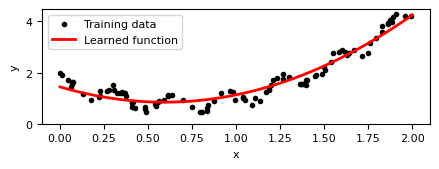

In [8]:
def training_loop(num_iterations, optimizer, model, loss_fn, x_train, y_train):
    for k in range(1, num_iterations + 1):        
        # Forward pass
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)            

        # Backward pass and parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print loss every 1000 iterations
        if k % 1000 == 0:
            print(f"Iteration {k:4d} | Loss = {loss.item():.6f}", flush=True)

# Prepare training data
x, y = generate_training_pairs()
y = y.unsqueeze(1)
x = torch.stack([x, x.pow(2)], dim=1)  # Input features: x and x^2

# Initialize model and optimizer
torch.manual_seed(0)
model = NeuralNetLinear()
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate) 

# Run training loop
training_loop(
    num_iterations=4000, 
    optimizer=optimizer,
    model=model,
    loss_fn=nn.MSELoss(),
    x_train=x,
    y_train=y
)

# Extract learned parameters
a = model.linear_model.bias.item()
b = model.linear_model.weight[0, 0].item()
c = model.linear_model.weight[0, 1].item()
print(f"Learned parameters: a = {a:.4f},  b = {b:.4f},  c = {c:.4f}")

# Plot result
plot_training_pairs_model(x[:, 0], y.squeeze(), para=[a, b, c])            

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> 
Parameter updates performed via <code>optimizer.step()</code> are automatically executed within a <code>torch.no_grad()</code> context. This prevents PyTorch's autograd engine from tracking the in-place changes to model parameters, which is essential for avoiding incorrect gradient computations. As a result, you should <strong>not</strong> wrap <code>optimizer.step()</code> in a <code>torch.no_grad()</code> block. This differs from earlier examples where parameters were updated manually using tensor operations and <code>torch.no_grad()</code> was required to disable gradient tracking.
</p>
</div>

<a id='secondexample'></a> 
## Example: Piecewise Linear Approximation

To further explore the capabilities of the `torch.nn` package, we now define a slightly more complex neural network. We continue using the training data from our previous example, but instead of using polynomial features (i.e., both `x` and `x**2`), we now aim to predict the target values `y` using only the original input tensor `x`. To capture the non-linear relationship between `x` and `y`, we design a neural network that implements a piecewise linear approximation using the following architecture:

* A first linear layer `nn.Linear(1, 3)` that projects the 1D input to a 3D space.
* A non-linear activation function `nn.ReLU()` applied elementwise.
* A second linear layer `nn.Linear(3, 1)` that maps the 3D result back to a 1D output.

Note that the output dimension of the first layer (which is `3`) must match the input dimension of the second layer. The activation function is applied component-wise and does not change the shape of the tensor. In the next code cell, we implement this network as a child class `NeuralNetTwoLayer` that inherits from the parent class `nn.Module`.

In [9]:
class NeuralNetTwoLayer(nn.Module):
    def __init__(self):
        super().__init__()
        # First linear layer: input dimension 1 -> hidden dimension 3
        self.linear1 = nn.Linear(in_features=1, out_features=3)
        # Non-linear activation function (ReLU)
        self.activation = nn.ReLU()
        # Second linear layer: hidden dimension 3 -> output dimension 1
        self.linear2 = nn.Linear(in_features=3, out_features=1)

    def forward(self, x):
        # Apply first linear transformation
        x = self.linear1(x)
        # Apply activation function
        x = self.activation(x)
        # Apply second linear transformation
        y = self.linear2(x)
        return y

In the next code cell, we instantiate the model, display its internal layer structure, and compute the total number of learnable parameters it contains. As an alternative, you may also try using the `summary` function from the `torchinfo` package, providing a detailed, layer-by-layer summary of a PyTorch model. Feel free to experiment with it on your own.

In [10]:
# Set random seed for reproducibility
torch.manual_seed(0)

# Instantiate the model and print the model architecture
model = NeuralNetTwoLayer()
print("Model structure:")
print(model)

# Print names, shapes, and number of elements for each parameter
print("Learnable parameters:")
for name, para in model.named_parameters():
    print(f"Name: {name}; Shape: {para.shape}; Number of elements: {para.numel()}")

# Compute and print the total number of trainable parameters in the model
total = sum(para.numel() for para in model.parameters())
print(f"Total number of parameters: {total}")

Model structure:
NeuralNetTwoLayer(
  (linear1): Linear(in_features=1, out_features=3, bias=True)
  (activation): ReLU()
  (linear2): Linear(in_features=3, out_features=1, bias=True)
)
Learnable parameters:
Name: linear1.weight; Shape: torch.Size([3, 1]); Number of elements: 3
Name: linear1.bias; Shape: torch.Size([3]); Number of elements: 3
Name: linear2.weight; Shape: torch.Size([1, 3]); Number of elements: 3
Name: linear2.bias; Shape: torch.Size([1]); Number of elements: 1
Total number of parameters: 10


In [11]:
# Alternative: Display a detailed summary of the model architecture using torchsummary
print("\nModel summary (using torchinfo):")
summary(model, input_size=(1,))


Model summary (using torchinfo):


Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetTwoLayer                        [1]                       --
├─Linear: 1-1                            [3]                       6
├─ReLU: 1-2                              [3]                       --
├─Linear: 1-3                            [1]                       4
Total params: 10
Trainable params: 10
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Note that, as mentioned earlier, the model parameters are randomly initialized. Even without training, the model can be directly applied to an input tensor of shape `(*, N)` to produce an output tensor of shape `(*, M)`. In the example above, we have `N = 1` and `M = 1`, while the `*` stands for an arbitrary batch dimension. This enables the model to process multiple input samples simultaneously. The following code cell demonstrates this behavior:

In [12]:
# Create input tensor with a batch of 4 samples, each having 1 feature
x_input = torch.tensor([[0], [1], [2], [3]], dtype=torch.float)
print("Input tensor of shape:", x_input.shape)
print(x_input)

# Pass the input batch through the model to obtain predictions
y_output = model(x_input)
print("\nOutput tensor of shape:", y_output.shape)
print(y_output)

Input tensor of shape: torch.Size([4, 1])
tensor([[0.],
        [1.],
        [2.],
        [3.]])

Output tensor of shape: torch.Size([4, 1])
tensor([[0.1390],
        [0.2220],
        [0.4676],
        [0.7132]], grad_fn=<AddmmBackward0>)


In the next code cell, we apply the model to our running example and visualize the output alongside the training samples. Thanks to the combination of two linear layers and the intermediate non-linear ReLU activation, the network is able to learn a piecewise linear function that effectively approximates the non-linear relationship between `x` and `y`.

Iteration 1000 | Loss = 0.126692


Iteration 2000 | Loss = 0.079341


Iteration 3000 | Loss = 0.071711


Iteration 4000 | Loss = 0.065949


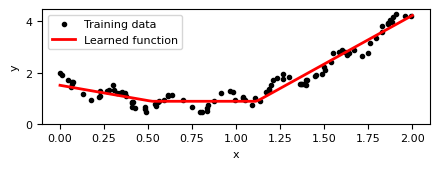

In [13]:
# Load training data and add dimension
x, y = generate_training_pairs()
x = x.unsqueeze(1)  # Shape: (*, 1)
y = y.unsqueeze(1)  # Shape: (*, 1)

# Set seed for reproducibility and initialize the model
torch.manual_seed(0)
model = NeuralNetTwoLayer()

# Train the model using a simple training loop
training_loop(
    num_iterations=4000,
    optimizer=optim.SGD(model.parameters(), lr=1e-2),
    model=model,
    loss_fn=nn.MSELoss(),
    x_train=x,
    y_train=y
)

# Visualize the learned model vs. training data
plot_training_pairs_model(x.squeeze(), y.squeeze(), model=model)

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> 
In PyTorch, the term <strong>layer</strong> can have two related but different meanings, which can be confusing at first. From the <strong>model definition viewpoint</strong>, a layer refers to a module that holds its own learnable parameters, such as an <code>nn.Linear</code> layer with a weight and bias. If the same layer is defined once but reused several times inside the <code>forward()</code> method, it still counts as one layer in the model structure because only one set of parameters is being learned. From the <strong>computational viewpoint</strong>, each time the input passes through this transformation, it represents another processing step in the data flow. In this sense, the network behaves as if it had multiple layers, even though they all share the same parameters. This distinction between <strong>structural depth</strong> and <strong>computational depth</strong> is illustrated in the following code cell.</p>
</div> 

In [14]:
# Define a simple neural network with shared weights
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        # One linear layer (1 input, 1 output), reused in forward pass
        self.linear_model = nn.Linear(1, 1)

    def forward(self, x):
        # Apply the same layer twice (two computation steps, shared parameters)
        x = self.linear_model(x)
        x = self.linear_model(x)
        return y

# Create model and print structure
model = NeuralNet()
print(model)

print("\nModel summary (using torchinfo):")
summary(model, input_size=(1,))

NeuralNet(
  (linear_model): Linear(in_features=1, out_features=1, bias=True)
)

Model summary (using torchinfo):


Layer (type:depth-idx)                   Output Shape              Param #
NeuralNet                                [100, 1]                  --
├─Linear: 1-1                            [1]                       2
├─Linear: 1-2                            [1]                       (recursive)
Total params: 2
Trainable params: 2
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

<a id='background_nonlinearity'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Nonlinearities and Activation Functions</h2>

<p style="color:#1B5E20;">
From a mathematical perspective, a function is considered <strong>nonlinear</strong> if it does not satisfy the principles of <strong>additivity</strong> and <strong>homogeneity</strong>, that is:
$$
f(\alpha \mathbf{x} + \beta \mathbf{y}) \ne \alpha f(\mathbf{x}) + \beta f(\mathbf{y})
$$
for arbitrary scalars $\alpha, \beta$ and vectors $\mathbf{x}, \mathbf{y}$. In contrast, <strong>linear functions</strong> are limited to representing transformations such as scaling, rotation, and translation. Their expressive power is inherently restricted. To illustrate this in the context of neural networks, consider composing two affine transformations:
$$
f(\mathbf{x}) = \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2.
$$
This composition simplifies to a single affine transformation:
$$
f(\mathbf{x}) = \mathbf{W} \mathbf{x} + \mathbf{b},
$$
where $\mathbf{W} = \mathbf{W}_2 \mathbf{W}_1$ and $\mathbf{b} = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2$. Therefore, stacking multiple linear layers without any nonlinear component results in a model that still behaves like a single linear transformation. Regardless of the depth, such networks cannot model complex nonlinear relationships or decision boundaries.
<br><br>
To overcome this limitation, neural networks incorporate <strong>nonlinear activation functions</strong> between layers. These functions break the linearity of the composition, enabling the network to learn and represent rich, nonlinear patterns in data. As a result, neural networks become <strong>universal function approximators</strong>&mdash;capable of modeling a wide range of nonlinear mappings under appropriate conditions. A typical neural network layer thus applies an affine transformation followed by a pointwise nonlinearity:
$$
\mathbf{y} = \sigma(\mathbf{W} \mathbf{x} + \mathbf{b}),
$$
where $\sigma$ is a nonlinear activation function applied elementwise. Common activation functions in deep learning include:
</p>

<ul style="color:#1B5E20;">
<li><strong>ReLU (Rectified Linear Unit):</strong> Defined as $\mathrm{ReLU}(x) = \max(0, x)$, it is simple and effective, promoting sparsity and avoiding vanishing gradients for positive inputs.</li>
<li><strong>Sigmoid:</strong> Maps real-valued inputs to the interval $(0, 1)$ via $\sigma(x) = (1 + e^{-x})^{-1}$. Historically important, but often suffers from vanishing gradients.</li>
<li><strong>Tanh:</strong> A zero-centered alternative to the sigmoid, mapping inputs to $(-1, 1)$. It still exhibits saturation at large input magnitudes.</li>
<li><strong>Leaky ReLU:</strong> A variant of ReLU that allows a small negative slope for $x < 0$, helping to avoid inactive (dead) neurons.</li>
<li><strong>Softmax:</strong> Converts a vector of raw scores into probabilities over multiple classes. Commonly used in multi-class classification tasks.</li>
</ul>

<p style="color:#1B5E20;">
These nonlinearities are essential to the expressive power of deep networks. Without them, even deep and wide architectures would collapse into simple linear models. The choice of activation function can strongly influence training dynamics, convergence behavior, and final model performance.
</p>
</div>

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> 
In this unit, we have only explored the fully connected layer, <code>nn.Linear</code>, and the non-linear activation function <code>nn.ReLU()</code> as examples of components within <code>nn.Module</code>. PyTorch offers a diverse range of additional modules, including <code>nn.Sequential</code> (a container module), <code>nn.Conv1d</code> (convolutional layer), <code>nn.RNN</code>, (recurrent layer), <code>nn.Dropout</code> (dropout regularization), <code>nn.BatchNorm1d</code> (batch normalization), as well as numerous activation functions. We will encounter some of these modules in later units.  For a comprehensive overview, please refer to the  <a href="https://pytorch.org/docs/stable/nn.html" target="_blank"><code>torch.nn</code> documentation</a>.
</p>
</div> 

<a id='exercise_activation_function'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Activation Functions</strong><br>

<p style="color:#006064;">
This exercise helps you explore the behavior of common nonlinear activation functions used in neural networks. Plot the following activation functions over a suitable input range (e.g., from −5 to 5), and write down their mathematical definitions:
</p>
<ul style="color:#006064;">
    <li><strong>ReLU</strong> (Rectified Linear Unit)</li> 
    <li><strong>Sigmoid</strong></li>     
    <li><strong>Tanh</strong> (Hyperbolic Tangent)</li>       
    <li><strong>Leaky ReLU</strong></li>    
</ul>
<p style="color:#006064;">
Furthermore, modify the two-layer network <code>NeuralNetTwoLayer</code> so that it accepts an arbitrary activation function as an input parameter. Then:
</p>
<ul style="color:#006064;">
    <li>Apply the network to the existing training data from our running example.</li>
    <li>Try out different activation functions and visualize the resulting model output.</li>    
    <li>In particular, also remove the activation function between the two layers by setting it to <code>nn.Identity()</code>, effectively creating a purely linear model.</li>
    <li>Experiment with different learning rates and numbers of training iterations to observe their effect on convergence and approximation quality.</li>
</ul>    
</div>

In [15]:
# Your Solution

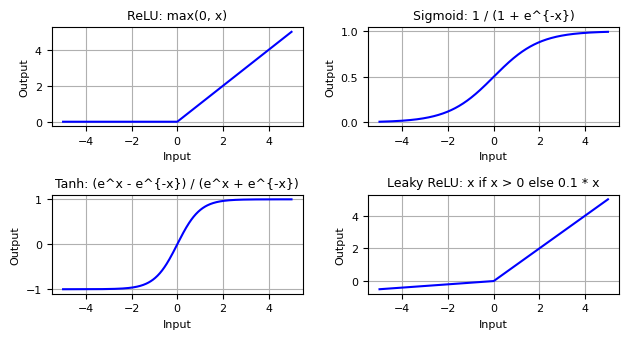

Activation function: ReLU; Learning rate: 0.01


Iteration 1000 | Loss = 0.126692


Iteration 2000 | Loss = 0.079341


Iteration 3000 | Loss = 0.071711


Iteration 4000 | Loss = 0.065949


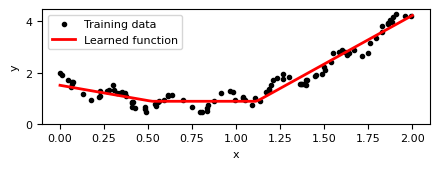

Activation function: Sigmoid; Learning rate: 0.1


Iteration 1000 | Loss = 0.142890


Iteration 2000 | Loss = 0.072504


Iteration 3000 | Loss = 0.059888


Iteration 4000 | Loss = 0.056696


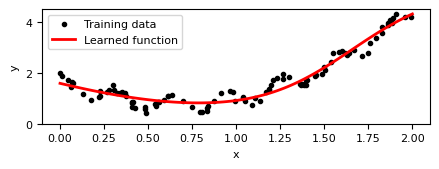

Activation function: Identity; Learning rate: 0.01


Iteration 1000 | Loss = 0.466556


Iteration 2000 | Loss = 0.466556


Iteration 3000 | Loss = 0.466556


Iteration 4000 | Loss = 0.466556


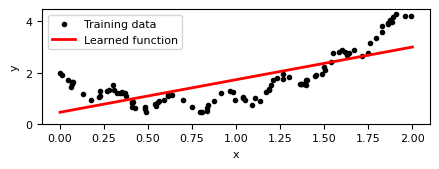

In [16]:
# Run and show output of the reference solution
exercise_activation_function()
exercise_activation_function_experiment()

<a id='exercises_model_capacity'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Exploring Model Capacity</strong><br><br>

<p style="color:#006064;">
In this exercise, you will extend the existing two-layer network <code>NeuralNetTwoLayer</code> by increasing both its depth (number of layers) and width (number of hidden units per layer), allowing the network to model more complex functions and investigate the effects of increased model capacity. Your tasks are as follows:
</p>

<ul style="color:#006064;">
  <li>
    Define a feedforward network class with four linear layers and non-linear activation functions in between. The class should accept <code>H</code> to specify the size of all hidden layers and <code>act</code> to determine the activation function applied between them. The network should follow the structure:<br>
    <code>Input (1D) -> Linear(1, H) -> act -> Linear(H, H) -> act -> Linear(H, H) -> act -> Linear(H, 1) -> Output (1D)</code>
  </li>
  <li>
    Create an instance of your network class, display its architecture, and compute the total number of trainable parameters.
  </li>
  <li>
    Generate a synthetic training dataset, e.g., using the following code:
   <ul style="color:#006064;">  
   <li><code>torch.manual_seed(0)</code></li>
   <li><code>x = torch.linspace(0.0, 2.2, steps=16).unsqueeze(1)</code></li>
   <li><code>y = torch.cos(2 * torch.pi * x) + 0.1 * torch.randn_like(x)</code></li>
   </ul>       
  </li>
  <li>
    Train your network on this dataset using <code>nn.MSELoss()</code> and <code>optim.SGD</code>.
  </li>
  <li>
    Visualize the model's output and compare it to the original training data.
  </li>
</ul>

<p style="color:#006064;">
Experiment with different configurations to observe how they affect convergence and approximation quality:
</p>
<ul style="color:#006064;">
  <li>Hidden dimension <code>H</code> (e.g., <code>3</code>, <code>10</code>, <code>50</code>)</li>    
  <li>Activation function <code>act</code> (e.g., <code>nn.ReLU()</code>, <code>nn.Sigmoid()</code>, <code>nn.Tanh()</code>)</li>
  <li>Learning rate <code>lr</code> (e.g., <code>0.01</code>, <code>0.05</code>, <code>0.1</code>)</li>
  <li>Number of training iterations (e.g., <code>2000</code>, <code>5000</code>, <code>10000</code>)</li>
</ul>

<p style="color:#006064;">
Explore and reflect on common training challenges such as:
</p>
<ul style="color:#006064;">
  <li><strong>Overfitting</strong> using a large model on a small dataset</li>
  <li><strong>Underfitting</strong> using a model that is too simple to capture the signal</li>
  <li><strong>Local minima</strong> or <strong>slow convergence</strong> caused by unsuitable learning rates or weight initialization</li>
</ul>
</div>

In [17]:
# Your Solution


Model summary (using torchinfo):
Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetFourLayer                       [1]                       --
├─Linear: 1-1                            [10]                      20
├─ReLU: 1-2                              [10]                      --
├─Linear: 1-3                            [10]                      110
├─ReLU: 1-4                              [10]                      --
├─Linear: 1-5                            [10]                      110
├─ReLU: 1-6                              [10]                      --
├─Linear: 1-7                            [1]                       11
Total params: 251
Trainable params: 251
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Training model: Four-Layer Network | Activation: ReLU | Hidden dim: 10 | Learning rate: 0.05


Iteration 1000 | Loss = 0.297972


Iteration 2000 | Loss = 0.083752


Iteration 3000 | Loss = 0.013272


Iteration 4000 | Loss = 0.009109


Iteration 5000 | Loss = 0.004498


Iteration 6000 | Loss = 0.000982


Iteration 7000 | Loss = 0.000000


Iteration 8000 | Loss = 0.000000


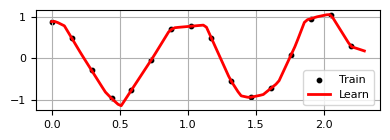


Conclusion: The model shows signs of overfitting: it fits the training data very well but the learned function is not a clean sinusoid. With 4 layers and 10 hidden units each, it has more capacity than necessary for this small dataset. As a result, it partially fits the noise in the data rather than capturing the underlying trend.


In [18]:
# Run and show output of the reference solution
exercises_model_capacity()

<a id='exercise_optimization'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Optimization</strong><br>

<p style="color:#006064;">
While simple gradient descent updates parameters in small steps along the negative gradient, more advanced optimization algorithms adapt this procedure for faster and more stable convergence. This exercise aims to demonstrate the behavior of different optimizers and optimizer configurations. We will use the Himmelblau function from <a href="PCPT_04_grad.html">Unit 4</a> as a test landscape for optimization:
$$
f(u, v) = (u^2 + v - 11)^2 + (u + v^2 - 7)^2
$$
</p>

<ul style="color:#006064;">
  <li>Initialize <code>u</code> and <code>v</code> as scalar tensors with <code>requires_grad=True</code> to enable automatic differentiation.</li>
  <li>Create an optimizer (e.g., <code>optim.SGD</code>) and pass <code>u</code> and <code>v</code> as parameters to be optimized.  </li>
  <li>Define the loss function as the Himmelblau function using standard PyTorch operations.</li>
  <li>Write a standard training loop consisting of:
    <ul style="color:#006064;">
        <li>Loss computation for the current values of <code>u</code> and <code>v</code>.</li>
        <li>Gradient reset to zero out gradients from past iterations: <code>optimizer.zero_grad()</code>.</li>
        <li>Backward pass for gradient computation: <code>loss.backward()</code>.</li>
        <li>Parameter update using the optimizer: <code>optimizer.step()</code>.</li>
    </ul>
</ul>

<p style="color:#006064;">
During training, store the current values of <code>u</code> and <code>v</code> in a list. After training, visualize the optimization trajectory by evaluating the Himmelblau function on a 2D grid and plotting it as a heatmap using <code>imshow</code>. Overlay the recorded <code>(u,v)</code> values from training using <code>plt.plot</code>.
<br><br>
Repeat above steps for different initial values for <code>u</code> and <code>v</code>, different optimizers, and different optimizer configurations. For example:   
</p>

<ul style="color:#006064;">
  <li>For <code>optim.SGD</code>, vary the <code>momentum</code> parameter and observe how it affects the choice and stability of the learning rate.</li>
  <li>Try alternative optimizers such as <code>optim.RMSprop</code> or <code>optim.Adam</code>. For a complete list of available options, refer to the <a href="https://pytorch.org/docs/stable/optim.html#algorithms" target="_blank">PyTorch documentation</a>.</li>
</ul>
</div>

In [19]:
# Your Solution

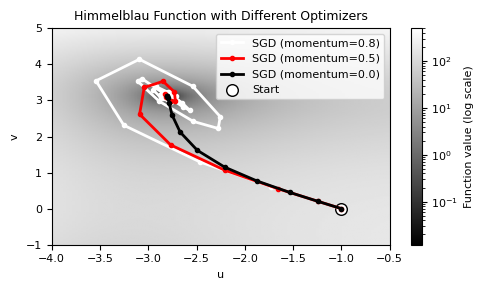

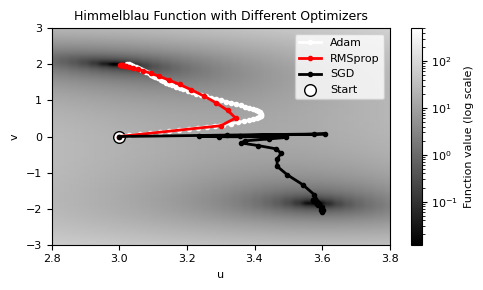

In [20]:
# Run and show output of the reference solution
exercise_optimization()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>